# <font color="darkblue"> Prática 01: Classificação binária com Redes Neurais </font>

**Objetivos:**


*   Utilizar a API Keras para classificação binária com redes neurais.

**Descrição:**

Com base em informações fornecidadas de 303 pessoas, as quais incluem idade, pressão arterial, nível de colesterol, frequência cardíaca, entre outros, crie uma rede neural para prever as chances de indivíduo ter um um infarto. Implemente as células cujos labels indicadores estão em vermelho.  

# <font color="darkblue"> Solução </font>

### Bibliotecas

In [2]:
import sys
import pandas as pd
import numpy as np
import sklearn
import matplotlib
import keras

print('Python: {}'.format(sys.version))
print('Pandas: {}'.format(pd.__version__))
print('Numpy: {}'.format(np.__version__))
print('Sklearn: {}'.format(sklearn.__version__))
print('Matplotlib: {}'.format(matplotlib.__version__))
print('Keras: {}'.format(keras.__version__))

Python: 3.12.11 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 08:03:38) [Clang 14.0.6 ]
Pandas: 2.3.2
Numpy: 2.0.1
Sklearn: 1.7.1
Matplotlib: 3.10.5
Keras: 3.11.2


### Leitura das instâncias

In [3]:
BATCH_SIZE = 16
RANDOM_STATE = 2

data = pd.read_csv("heart.csv")

X = np.array(data.drop(['output'], axis=1))
y = np.array(data['output'])

### Explorando os dados

In [4]:
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns

print(f"Shape: {data.shape}")
data.head()

Shape: (303, 14)


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


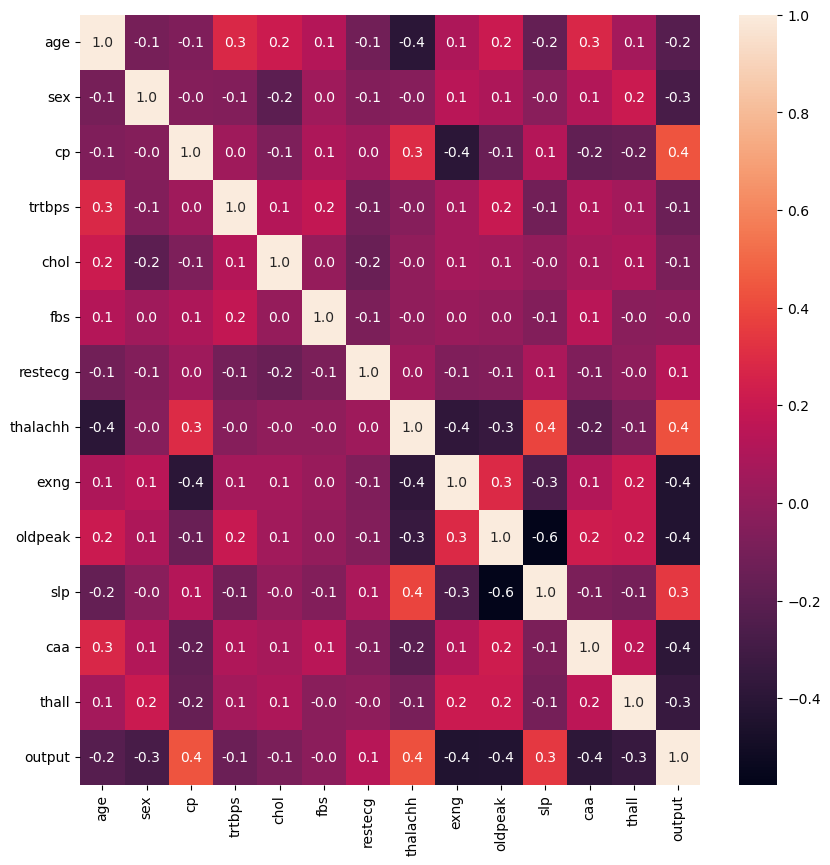

In [5]:
plt.figure(figsize=(10,10))
sns.heatmap(data.corr(), annot=True, fmt='.1f')
plt.show()

### Criando a rede neural

In [7]:
from keras.models import Sequential
from keras.layers import Dense, Input
from keras import optimizers
from sklearn import model_selection
from keras import regularizers

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, random_state=RANDOM_STATE, test_size=0.2)

# Criando a arquitetura da rede neural
model = Sequential()

# Entrada
model.add(Input(shape=(13,)))

# Camadas escondidas
model.add(Dense(8, kernel_initializer='normal', activation='tanh'))

# Camada de saída
model.add(Dense(1, kernel_initializer='normal', activation='sigmoid'))

# Obtém os pesos iniciais da rede
initial_weights = model.get_weights()

# Instanciação e configuração de otimizadores
sgd = optimizers.SGD(learning_rate=0.01)

# Compila o modelo
model.compile(loss='binary_crossentropy', optimizer=sgd, metrics=['accuracy'])

print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121 (484.00 B)

 Trainable params: 121 (484.00 B)

 Non-trainable params: 0 (0.00 B)

None


### Treinando a rede neural

In [ ]:
model.set_weights(initial_weights)
history = model.fit(X_train, y_train, epochs=100, batch_size=BATCH_SIZE)

4/4 [==============================] - 0s 1ms/step - loss: 0.6841 - accuracy: 0.5620
Epoch 84/100
4/4 [==============================] - 0s 712us/step - loss: 0.6839 - accuracy: 0.5620
Epoch 85/100
4/4 [==============================] - 0s 973us/step - loss: 0.6838 - accuracy: 0.5620
Epoch 86/100
4/4 [==============================] - 0s 704us/step - loss: 0.6839 - accuracy: 0.5620
Epoch 87/100
4/4 [==============================] - 0s 1ms/step - loss: 0.6839 - accuracy: 0.5620
Epoch 88/100
4/4 [==============================] - 0s 913us/step - loss: 0.6838 - accuracy: 0.5620
Epoch 89/100
4/4 [==============================] - 0s 925us/step - loss: 0.6836 - accuracy: 0.5620
Epoch 90/100
4/4 [==============================] - 0s 795us/step - loss: 0.6834 - accuracy: 0.5620
Epoch 91/100
4/4 [==============================] - 0s 774us/step - loss: 0.6834 - accuracy: 0.5620
Epoch 92/100
4/4 [==============================] - 0s 649us/step - loss: 0.6835 - accuracy: 0.5620
Epoch 93/100
4/4 

### Performance do modelo

In [ ]:
from sklearn.metrics import accuracy_score

plt.plot(history.history['loss'])
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Epoca')
plt.legend(['Treinamento'])
plt.show()

# Obtendo a acuracia no conjunto de treinamento
E_in, acc_train = model.evaluate(X_train, y_train, batch_size=BATCH_SIZE, verbose=0)

# Obtendo a acuracia no conjunto de teste
E_out, acc_test = model.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=0)

print(f'\n--> Acuracia (treino): {acc_train:.4f}')
print(f'--> Acuracia (teste): {acc_test:.4f}')
print(f"--> E_out - E_in = {E_out - E_in:.4f}")
print(f"--> acc_train - acc_test = {acc_train - acc_test:.4f}")

<span style="color:red; font-size: 17px; font-weight: bold;">Crie uma rede neural usando a teoria da Dimensão VC para determinar o número máximo de neurônios $n$ na camada escondida:</span>
</br></br>

<span style="color:red; font-size: 20px">
 $n \le \lfloor \frac{\lvert CT \rvert - 10}{10\times (d+2)} \rfloor  $ 
</span>

In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras import optimizers
from sklearn import model_selection


# Divida os dados em treino e teste

# Crie a arquitetura da rede neural. Configure a rede a partir
# de informações da dimensão VC e da regra de ouro

# Obtém os pesos iniciais da rede
initial_weights = model.get_weights()

# Gradiente Descendente
sgd = optimizers.SGD(learning_rate=0.01)  

# Compile o modelo

print(model.summary())

### Usando validação para verificar se há overfitting

In [ ]:
X_train, X_val, y_train, y_val = model_selection.train_test_split(X_train, y_train, random_state=RANDOM_STATE, test_size=0.2)

model.set_weights(initial_weights)
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=BATCH_SIZE)

Epoch 59/100
13/13 [==============================] - 0s 1ms/step - loss: 0.6850 - accuracy: 0.5648 - val_loss: 0.6893 - val_accuracy: 0.5510
Epoch 60/100
13/13 [==============================] - 0s 1ms/step - loss: 0.6852 - accuracy: 0.5648 - val_loss: 0.6894 - val_accuracy: 0.5510
Epoch 61/100
13/13 [==============================] - 0s 1ms/step - loss: 0.6853 - accuracy: 0.5648 - val_loss: 0.6896 - val_accuracy: 0.5510
Epoch 62/100
13/13 [==============================] - 0s 1ms/step - loss: 0.6852 - accuracy: 0.5648 - val_loss: 0.6892 - val_accuracy: 0.5510
Epoch 63/100
13/13 [==============================] - 0s 1ms/step - loss: 0.6851 - accuracy: 0.5648 - val_loss: 0.6889 - val_accuracy: 0.5510
Epoch 64/100
13/13 [==============================] - 0s 1ms/step - loss: 0.6850 - accuracy: 0.5648 - val_loss: 0.6890 - val_accuracy: 0.5510
Epoch 65/100
13/13 [==============================] - 0s 1ms/step - loss: 0.6850 - accuracy: 0.5648 - val_loss: 0.6892 - val_accuracy: 0.5510
Epoch 

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Epoca')
plt.legend(['Treinamento', 'Validacao'])
plt.show()

# Obtendo a acuracia no conjunto de treinamento
E_in, acc_train = model.evaluate(X_train, y_train, batch_size=BATCH_SIZE, verbose=0)

# Obtendo a acuracia no conjunto de validacao
E_val, acc_val = model.evaluate(X_val, y_val, batch_size=BATCH_SIZE, verbose=0)

print(f"--> E_val - E_in = {E_val - E_in:.4f}")
print(f'--> Acuracia (treino): {acc_train:.4f}')
print(f'--> Acuracia (validacao): {acc_val:.4f}')
print(f"--> acc_train - acc_test = {acc_train - acc_val:.4f}")

<span style="color:red; font-size: 18px; font-weight: bold;">Crie uma rede neural para gerar overfitting</span>

In [ ]:
# Normalizacao de dados
min_values = X.min(axis=0)
max_values = X.max(axis=0)
X = (X - min_values) / (max_values - min_values)

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, random_state=RANDOM_STATE, test_size=0.2)
X_train, X_val, y_train, y_val = model_selection.train_test_split(X_train, y_train, random_state=RANDOM_STATE, test_size=0.2)


# CONTINUE AQUI O RESTANTE DO CÓDIGO

### Tratando o overfitting

In [ ]:
from keras.layers import Dropout
from keras import regularizers
from keras.callbacks import EarlyStopping

# Criando a arquitetura da rede neural
model = Sequential()

model.add(Dense(100, input_dim=13, kernel_initializer='normal', kernel_regularizer=regularizers.l2(0.01), activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(100, kernel_initializer='normal', kernel_regularizer=regularizers.l2(0.01), activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, kernel_initializer='normal', activation='sigmoid'))

es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)

# Compilar o modelo
model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])

print(model.summary())

Epoch 53/200
13/13 [==============================] - 0s 2ms/step - loss: 0.4634 - accuracy: 0.8135 - val_loss: 0.4215 - val_accuracy: 0.8571
Epoch 54/200
13/13 [==============================] - 0s 2ms/step - loss: 0.4765 - accuracy: 0.8187 - val_loss: 0.4264 - val_accuracy: 0.7959
Epoch 55/200
13/13 [==============================] - 0s 2ms/step - loss: 0.4693 - accuracy: 0.7876 - val_loss: 0.4342 - val_accuracy: 0.7959
Epoch 56/200
13/13 [==============================] - 0s 2ms/step - loss: 0.4489 - accuracy: 0.8342 - val_loss: 0.4186 - val_accuracy: 0.8571
Epoch 57/200
13/13 [==============================] - 0s 2ms/step - loss: 0.4542 - accuracy: 0.8342 - val_loss: 0.4228 - val_accuracy: 0.8163
Epoch 58/200
13/13 [==============================] - 0s 2ms/step - loss: 0.4528 - accuracy: 0.8394 - val_loss: 0.4294 - val_accuracy: 0.7959
Epoch 59/200
13/13 [==============================] - 0s 2ms/step - loss: 0.4455 - accuracy: 0.8394 - val_loss: 0.4279 - val_accuracy: 0.8163
Epoch 

13/13 [==============================] - 0s 2ms/step - loss: 0.4263 - accuracy: 0.8394 - val_loss: 0.4374 - val_accuracy: 0.7755
Epoch 111/200
13/13 [==============================] - 0s 2ms/step - loss: 0.4434 - accuracy: 0.8031 - val_loss: 0.4109 - val_accuracy: 0.8163
Epoch 112/200
13/13 [==============================] - 0s 2ms/step - loss: 0.4334 - accuracy: 0.8394 - val_loss: 0.4090 - val_accuracy: 0.8163
Epoch 113/200
13/13 [==============================] - 0s 2ms/step - loss: 0.4435 - accuracy: 0.8187 - val_loss: 0.4116 - val_accuracy: 0.7755
Epoch 114/200
13/13 [==============================] - 0s 2ms/step - loss: 0.4331 - accuracy: 0.8290 - val_loss: 0.4066 - val_accuracy: 0.8163
Epoch 115/200
13/13 [==============================] - 0s 2ms/step - loss: 0.4258 - accuracy: 0.8394 - val_loss: 0.4144 - val_accuracy: 0.7755
Epoch 116/200
13/13 [==============================] - 0s 2ms/step - loss: 0.4269 - accuracy: 0.8497 - val_loss: 0.4030 - val_accuracy: 0.8571
Epoch 117/200

13/13 [==============================] - 0s 2ms/step - loss: 0.4165 - accuracy: 0.8446 - val_loss: 0.4012 - val_accuracy: 0.8776
Epoch 168/200
13/13 [==============================] - 0s 2ms/step - loss: 0.4090 - accuracy: 0.8446 - val_loss: 0.4002 - val_accuracy: 0.8571
Epoch 169/200
13/13 [==============================] - 0s 2ms/step - loss: 0.4039 - accuracy: 0.8497 - val_loss: 0.3993 - val_accuracy: 0.8367
Epoch 170/200
13/13 [==============================] - 0s 2ms/step - loss: 0.4015 - accuracy: 0.8549 - val_loss: 0.4067 - val_accuracy: 0.8571
Epoch 171/200
13/13 [==============================] - 0s 2ms/step - loss: 0.4034 - accuracy: 0.8446 - val_loss: 0.4020 - val_accuracy: 0.8776
Epoch 172/200
13/13 [==============================] - 0s 2ms/step - loss: 0.4026 - accuracy: 0.8497 - val_loss: 0.4010 - val_accuracy: 0.8776
Epoch 173/200
13/13 [==============================] - 0s 2ms/step - loss: 0.4070 - accuracy: 0.8497 - val_loss: 0.4014 - val_accuracy: 0.8776
Epoch 174/200

In [ ]:
model.set_weights(initial_weights)

#history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=200, batch_size=BATCH_SIZE, callbacks=[es])
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=200, batch_size=BATCH_SIZE)

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Epoca')
plt.legend(['Treinamento', 'Validacao'])
plt.show()

# Obtendo a acuracia no conjunto de treinamento
E_in, acc_train = model.evaluate(X_train, y_train, batch_size=BATCH_SIZE, verbose=0)

# Obtendo a acuracia no conjunto de validacao
E_val, acc_val = model.evaluate(X_val, y_val, batch_size=BATCH_SIZE, verbose=0)

print(f"--> E_val - E_in = {E_val - E_in:.4f}")
print(f'--> Acuracia (treino): {acc_train:.4f}')
print(f'--> Acuracia (validacao): {acc_val:.4f}')
print(f"--> acc_train - acc_test = {acc_train - acc_val:.4f}")

### Usando o K-Fold Cross Validation para validar o modelo usando todo o conjunto de treinamento

In [ ]:
from sklearn.model_selection import StratifiedKFold

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, random_state=RANDOM_STATE, test_size=0.2)

# Garante o balanceamento nos folds
skf = StratifiedKFold(n_splits=5, shuffle=True)

accuracies_train = []
accuracies_val = []
history_list = []
ein_list = []
eval_list = []

# Realiza o k-fold cross validation
i = 0
for train_index, val_index in skf.split(X_train, y_train):
    i = i + 1
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]
    
    # Criando a arquitetura da rede neural    
    model = Sequential()
    
    # Model 1
    '''
    model.add(Dense(10, input_dim=13, kernel_initializer='normal', kernel_regularizer=regularizers.l2(0.01), activation='relu'))
    #model.add(Dropout(0.2))
    model.add(Dense(10, kernel_initializer='normal', kernel_regularizer=regularizers.l2(0.01), activation='relu'))
    #model.add(Dropout(0.2))
    model.add(Dense(1, kernel_initializer='normal', activation='sigmoid'))
    '''
    
    # Model 2
    model.add(Dense(2, input_dim=13, kernel_initializer='normal', activation='relu'))
    model.add(Dense(1, kernel_initializer='normal', activation='sigmoid'))

    # Compilar o modelo
    model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])
  
    # Treina o modelo
    history = model.fit(X_train_fold, y_train_fold, validation_data=(X_val_fold, y_val_fold), epochs=200, batch_size=8, verbose=0)
    history_list.append(history) 
    
    # Avalia o modelo
    E_in, accuracy_train = model.evaluate(X_train_fold, y_train_fold, batch_size=BATCH_SIZE, verbose=0)
    E_val, accuracy_val = model.evaluate(X_val_fold, y_val_fold, batch_size=BATCH_SIZE, verbose=0)
    
    accuracies_train.append(accuracy_train)
    accuracies_val.append(accuracy_val)
    ein_list.append(E_in)
    eval_list.append(E_val)    
    
    # Exibe o historico de treinamento para um fold especifico
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'Metrica de erro - Fold {i}')
    plt.ylabel('Erro')
    plt.xlabel('Epoca')
    plt.legend(['Treinamento'])
    plt.show()

    print(f'--> Acuracia (treino): {accuracy_train:.4f}')
    print(f'--> Acuracia (validacao): {accuracy_val:.4f}')
    print(f"--> E_val - E_in = {E_val - E_in:.4f}")
    print(f"--> acc_in - acc_val = {accuracy_train - accuracy_val:.4f}\n")    

# Calcula a acuracia media
avg_accuracy_train = np.mean(accuracies_train)
avg_accuracy_val = np.mean(accuracies_val)
avg_ein = np.mean(ein_list)
avg_eval = np.mean(eval_list)

# Historico com valores medios dos folds
history_loss_avg = []
history_val_loss_avg = []
aux_list1 = []
aux_list2 = []

for i in range(len(history.history['loss'])):
    for j in range(len(history_list)):
        aux_list1.append(history_list[j].history['loss'][i])
        aux_list2.append(history_list[j].history['val_loss'][i])
    history_loss_avg.append(np.mean(aux_list1))
    history_val_loss_avg.append(np.mean(aux_list2))                            
                   
plt.plot(history_loss_avg)
plt.plot(history_val_loss_avg)
plt.title('Metrica de erro - Media dos Folds')
plt.ylabel('Erro')
plt.xlabel('Epoca')
plt.legend(['Treinamento'])
plt.show()

print(f'--> Acuracia (treino): {avg_accuracy_train:.4f}')
print(f'--> Acuracia (validacao): {avg_accuracy_val:.4f}')
print(f"--> E_in = {avg_ein:.4f}")
print(f"--> E_val = {avg_eval:.4f}")
print(f"--> E_val - E_in = {avg_eval - avg_ein:.4f}")
print(f"--> acc_in - acc_val = {avg_accuracy_train - avg_accuracy_val:.4f}\n")    

### Avaliando o modelo no conjunto de teste

In [ ]:
# Obtendo a acuracia no conjunto de teste
E_out, acc_test = model.evaluate(X_test, y_test, verbose=0)

print(f"--> E_out = {E_out:.4f}")
print(f'--> Acuracia (teste): {acc_test:.4f}')